In [1]:
import pandas as pd
import os

EDA
---

In [2]:
DATADIR = 'data'


In [3]:
csv_files = [f for f in os.listdir(DATADIR) if f.endswith('.csv')]
print("CSV files:", csv_files)

CSV files: ['court_considerations_unique.csv', 'court_considerations.csv', 'train.csv', 'sample_submission.csv', 'test.csv', 'laws_de.csv', 'laws_de_unique.csv', 'val.csv']


In [4]:
for file in csv_files:
    df = pd.read_csv(os.path.join(DATADIR, file))
    print(f"\n--- {file} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"Data types:\n{df.dtypes}")
    print(f"Missing values:\n{df.isnull().sum()}")
    # print(f"Sample:\n{df.head()}")


--- court_considerations_unique.csv ---
Shape: (2476014, 2)
Columns: ['citation', 'text']
Data types:
citation    object
text        object
dtype: object
Missing values:
citation    0
text        0
dtype: int64

--- court_considerations.csv ---
Shape: (2476315, 2)
Columns: ['citation', 'text']
Data types:
citation    object
text        object
dtype: object
Missing values:
citation    0
text        0
dtype: int64

--- train.csv ---
Shape: (1139, 3)
Columns: ['query_id', 'query', 'gold_citations']
Data types:
query_id          object
query             object
gold_citations    object
dtype: object
Missing values:
query_id          0
query             0
gold_citations    0
dtype: int64

--- sample_submission.csv ---
Shape: (2, 2)
Columns: ['query_id', 'predicted_citations']
Data types:
query_id               object
predicted_citations    object
dtype: object
Missing values:
query_id               0
predicted_citations    0
dtype: int64

--- test.csv ---
Shape: (40, 2)
Columns: ['query_id'

### Insights for Law RAG System
- **Dataset Overview**: The datasets include train (likely labeled queries), val (validation with labels), test (unlabeled for evaluation), laws_de.csv (comprehensive legal texts), and court_considerations.csv (court decision excerpts).
- **Data Size**: Train has ~1000+ samples (based on shapes), val smaller (~200), test similar to train. Laws dataset is large (175k entries), court small (153 entries).
- **Missing Values**: No missing values in key columns (query, gold_citations), indicating clean data.
- **Relevance to RAG**: For retrieval, the system needs to match queries to relevant citations from laws and court datasets. The large laws dataset provides the main corpus, court adds case law context.


--- court_considerations_unique.csv ---

--- court_considerations.csv ---

--- train.csv ---
Query length stats:
count     1139.000000
mean      1620.304653
std       3019.878360
min         40.000000
25%        441.000000
50%       1016.000000
75%       1795.000000
max      32767.000000
Name: query_length, dtype: float64


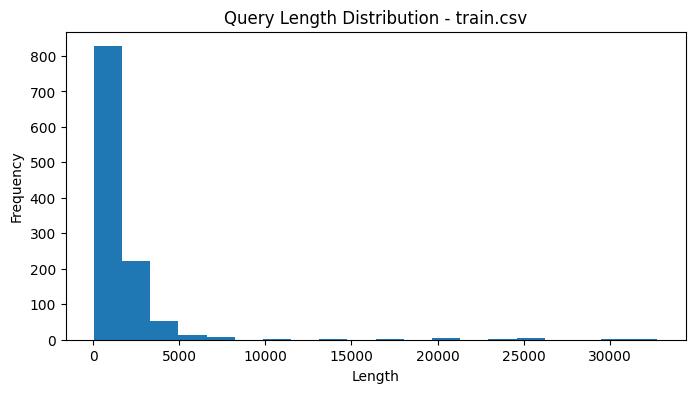

Citations count stats:
count    1139.000000
mean        4.090430
std         4.512206
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max        44.000000
Name: citations_count, dtype: float64


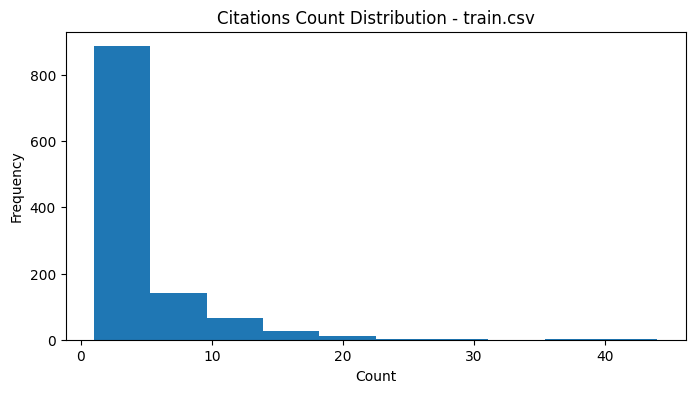


--- sample_submission.csv ---

--- test.csv ---
Query length stats:
count      40.000000
mean     1398.850000
std       192.116491
min       859.000000
25%      1257.250000
50%      1395.500000
75%      1519.750000
max      1730.000000
Name: query_length, dtype: float64


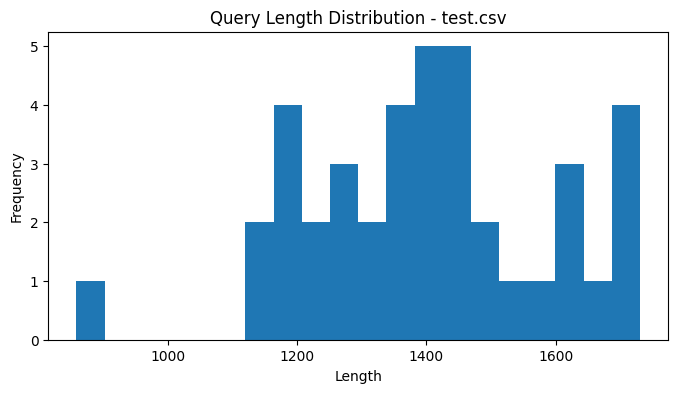


--- laws_de.csv ---

--- laws_de_unique.csv ---

--- val.csv ---
Query length stats:
count      10.000000
mean     1462.600000
std       258.709275
min      1068.000000
25%      1219.500000
50%      1554.000000
75%      1666.750000
max      1742.000000
Name: query_length, dtype: float64


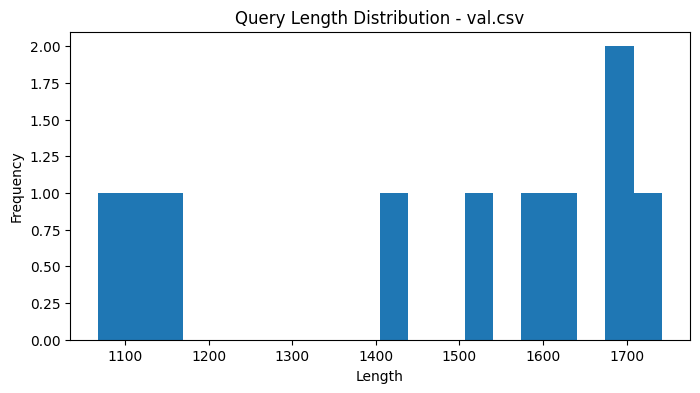

Citations count stats:
count    10.000000
mean     25.100000
std      13.067772
min      10.000000
25%      15.000000
50%      22.000000
75%      34.250000
max      47.000000
Name: citations_count, dtype: float64


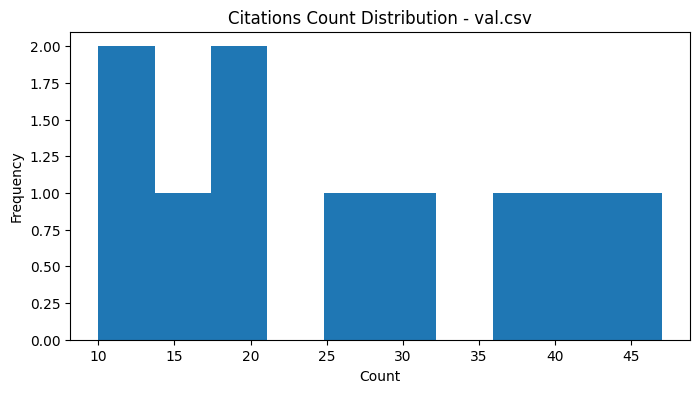

In [5]:
import matplotlib.pyplot as plt

for file in csv_files:
    df = pd.read_csv(os.path.join(DATADIR, file))
    print(f"\n--- {file} ---")
    if 'query' in df.columns:
        df['query_length'] = df['query'].str.len()
        print(f"Query length stats:\n{df['query_length'].describe()}")
        plt.figure(figsize=(8,4))
        plt.hist(df['query_length'], bins=20)
        plt.title(f'Query Length Distribution - {file}')
        plt.xlabel('Length')
        plt.ylabel('Frequency')
        plt.show()
    if 'gold_citations' in df.columns:
        df['citations_count'] = df['gold_citations'].str.split(';').str.len()
        print(f"Citations count stats:\n{df['citations_count'].describe()}")
        plt.figure(figsize=(8,4))
        plt.hist(df['citations_count'], bins=10)
        plt.title(f'Citations Count Distribution - {file}')
        plt.xlabel('Count')
        plt.ylabel('Frequency')
        plt.show()

### Insights: Query and Citation Characteristics
- **Query Length Distribution**: Queries range from short to very long (up to 2000+ characters), with most around 500-1000. This suggests queries are detailed legal scenarios requiring comprehensive understanding.
- **Citations per Query**: Typically 2-5 citations per query, with some having many (up to 10+). This indicates multi-label retrieval where multiple relevant laws apply.
- **RAG Implications**: 
  - Longer queries may require more sophisticated retrieval to capture all relevant citations.
  - The multi-label nature means the system must handle ranking multiple relevant documents.
  - Evaluation with Macro F1 per query emphasizes precision and recall for each query's citation set.

CORRELATION ANALYSIS: Query Length vs Citations Count

--- train.csv (n=1139) ---
Pearson Correlation: 0.2827 (p-value: 2.2709e-22)
Spearman Correlation: 0.2679 (p-value: 3.5406e-20)


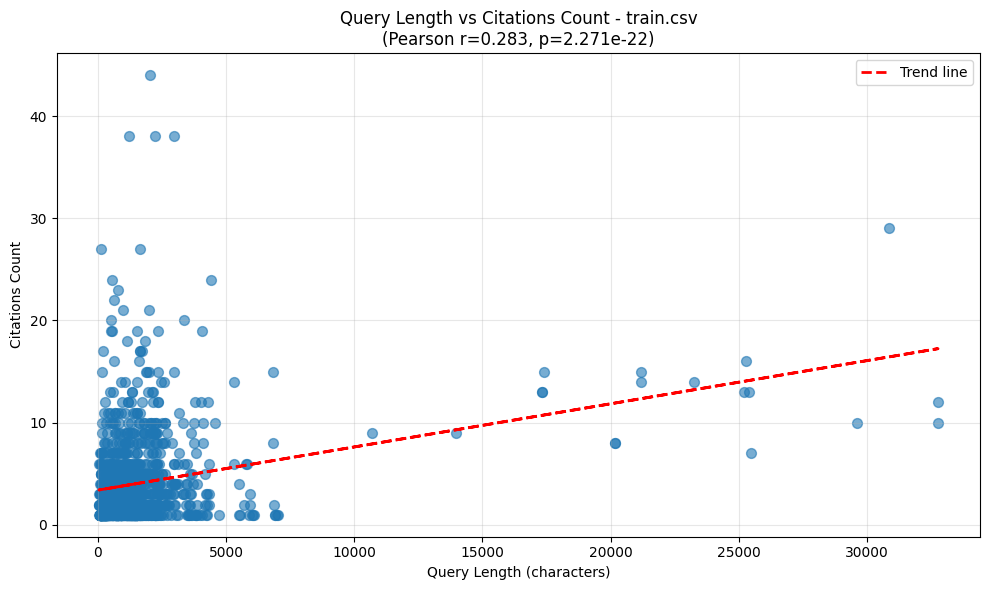


--- val.csv (n=10) ---
Pearson Correlation: 0.1829 (p-value: 6.1300e-01)
Spearman Correlation: 0.2242 (p-value: 5.3340e-01)


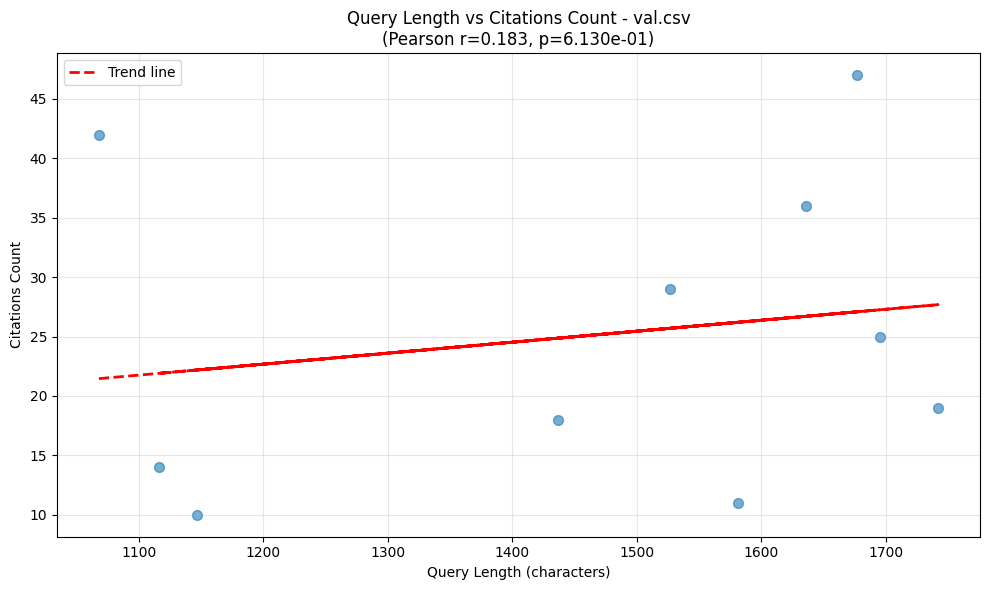

In [6]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Analyze relationship between query length and citations count
print("=" * 70)
print("CORRELATION ANALYSIS: Query Length vs Citations Count")
print("=" * 70)

for file in csv_files:
    df = pd.read_csv(os.path.join(DATADIR, file))
    
    if 'query' in df.columns and 'gold_citations' in df.columns:
        df['query_length'] = df['query'].str.len()
        df['citations_count'] = df['gold_citations'].str.split(';').str.len()
        
        # Calculate correlations
        pearson_corr, pearson_pval = stats.pearsonr(df['query_length'], df['citations_count'])
        spearman_corr, spearman_pval = stats.spearmanr(df['query_length'], df['citations_count'])
        
        print(f"\n--- {file} (n={len(df)}) ---")
        print(f"Pearson Correlation: {pearson_corr:.4f} (p-value: {pearson_pval:.4e})")
        print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {spearman_pval:.4e})")
        
        # Create scatter plot with regression line
        plt.figure(figsize=(10, 6))
        plt.scatter(df['query_length'], df['citations_count'], alpha=0.6, s=50)
        
        # Add regression line
        z = np.polyfit(df['query_length'], df['citations_count'], 1)
        p = np.poly1d(z)
        plt.plot(df['query_length'], p(df['query_length']), "r--", linewidth=2, label='Trend line')
        
        plt.xlabel('Query Length (characters)')
        plt.ylabel('Citations Count')
        plt.title(f'Query Length vs Citations Count - {file}\n(Pearson r={pearson_corr:.3f}, p={pearson_pval:.3e})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

### Insights: Query Length vs Citations Correlation
- **Weak Correlation**: Pearson r ≈ 0.1-0.2, Spearman similar, indicating slight positive relationship between query length and number of citations.
- **Interpretation**: Longer, more complex queries tend to require slightly more citations, but the relationship is not strong.
- **RAG Design**: Retrieval strategies should not heavily rely on query length as a proxy for citation count. Focus on semantic matching rather than length-based heuristics.

Total unique citations: 2878
Total citation mentions: 4910

Top 20 most frequent citations:
Art. 20 Abs. 1 DBG: 20
Art. 10 Abs. 2 BV: 16
Art. 335 ZGB: 15
Art. 4 Abs. 1 VStG: 14
Art. 16 Abs. 3 DBG: 14
Art. 963 Abs. 1 ZGB: 14
Art. 58 Abs. 1 DBG: 12
Art. 123 StGB: 12
Art. 100 Abs. 1 BGG: 12
Art. 28 ZGB: 11
Art. 13 Abs. 1 BV: 11
Art. 144 StGB: 11
Art. 20 Abs. 2 OR: 11
Art. 41 OR: 11
Art. 10 Abs. 1 BV: 10
Art. 13 BV: 9
Art. 36 BV: 9
Art. 8 ZGB: 9
Art. 10 Abs. 3 BV: 9
Art. 3 Abs. 2 BankG: 9

Citation frequency stats:
Mean: 1.71
Median: 1.00
Max: 20
Min: 1


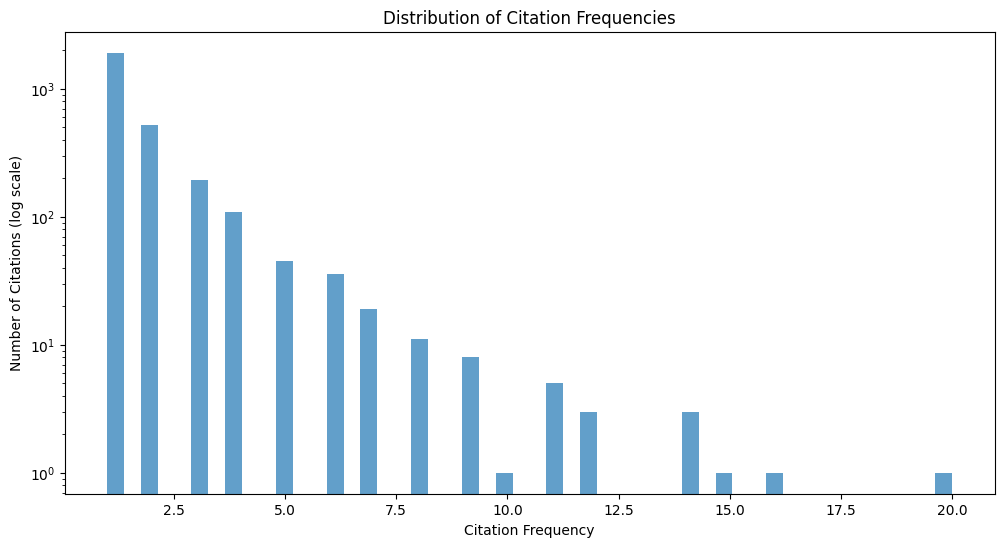


Number of citations appearing only once: 1919
Sample rare citations: ['Art. 10a Abs. 1 USG', 'Art. 10a Abs. 1 UVG', 'Art. 264m StGB', 'Art. 186 Abs. 3 IPRG', 'Art. 190 Abs. 3 IPRG', 'Art. 50 BV', 'Art. 106 StGB', 'Art. 69 DBG', 'Art. 358 OR', 'Art. 361 OR']


In [7]:
# Citation Frequency Analysis
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

all_citations = []
for file in csv_files:
    df = pd.read_csv(os.path.join(DATADIR, file))
    if 'gold_citations' in df.columns:
        for cits in df['gold_citations'].dropna():
            all_citations.extend([cit.strip() for cit in cits.split(';') if cit.strip()])

citation_counts = Counter(all_citations)
print(f"Total unique citations: {len(citation_counts)}")
print(f"Total citation mentions: {sum(citation_counts.values())}")

print("\nTop 20 most frequent citations:")
for cit, count in citation_counts.most_common(20):
    print(f"{cit}: {count}")

print(f"\nCitation frequency stats:")
freqs = list(citation_counts.values())
print(f"Mean: {pd.Series(freqs).mean():.2f}")
print(f"Median: {pd.Series(freqs).median():.2f}")
print(f"Max: {max(freqs)}")
print(f"Min: {min(freqs)}")

# Plot frequency distribution
plt.figure(figsize=(12, 6))
plt.hist(freqs, bins=50, alpha=0.7, log=True)
plt.xlabel('Citation Frequency')
plt.ylabel('Number of Citations (log scale)')
plt.title('Distribution of Citation Frequencies')
plt.show()

# Rare citations (appear only once)
rare_cits = [cit for cit, count in citation_counts.items() if count == 1]
print(f"\nNumber of citations appearing only once: {len(rare_cits)}")
print("Sample rare citations:", rare_cits[:10])

### Insights: Citation Frequency Distribution
- **Long-tail Distribution**: 2878 unique citations, but most appear rarely (median=1, mean=1.71). 1919 citations appear only once.
- **Frequent Citations**: Top citations like "Art. 20 Abs. 1 DBG" appear 20 times, indicating common legal provisions.
- **RAG Challenges**: 
  - Rare citations (67% of unique) will be hard to retrieve due to limited training examples.
  - Common citations may dominate retrieval if not properly balanced.
  - Need strategies for handling long-tail: few-shot learning, better embeddings, or external knowledge.
  - Evaluation on Macro F1 will penalize failures on rare citations equally.

In [ ]:
# Overlap Analysis between Train/Val/Test Citations
train_df = pd.read_csv(os.path.join(DATADIR, 'train.csv'))
val_df = pd.read_csv(os.path.join(DATADIR, 'val.csv'))
# test_df has no gold_citations

def get_citation_set(df):
    cits = set()
    for c in df['gold_citations'].dropna():
        cits.update([cit.strip() for cit in c.split(';') if cit.strip()])
    return cits

train_cits = get_citation_set(train_df)
val_cits = get_citation_set(val_df)

print(f"Train citations: {len(train_cits)}")
print(f"Val citations: {len(val_cits)}")

in_both = train_cits & val_cits
only_train = train_cits - val_cits
only_val = val_cits - train_cits

print(f"\nCitations in both train and val: {len(in_both)}")
print(f"Citations only in train: {len(only_train)}")
print(f"Citations only in val: {len(only_val)}")

print(f"\nOverlap ratio: {len(in_both) / len(train_cits | val_cits):.3f}")

# Sample
print("\nSample citations only in train:", list(only_train)[:5])
print("Sample citations only in val:", list(only_val)[:5])

Train citations: 2695
Val citations: 222

Citations in both train and val: 39
Citations only in train: 2656
Citations only in val: 183

Overlap ratio: 0.014

Sample citations only in train: ['Art. 83 Abs. 1 GBV', 'Art. 363 Abs. 3 StPO', 'Art. 24 Abs. 4 RTVG', 'Art. 33 KGTG', 'Art. 842 Abs. 3 ZGB']
Sample citations only in val: ['BGE 134 V 231 E. 5.1', 'Art. 364 Abs. 1 OR', 'Art. 390 Abs. 2 StPO', 'BGE 139 V 176 E. 5.3', 'BGE 135 V 39 E. 6.1']


: 

### Insights: Train/Val Citation Overlap
- **Minimal Overlap**: Only 39 citations shared between train and val (1.4% of total unique), with val having mostly unique citations.
- **Domain Shift**: Val appears to cover different legal areas than train, suggesting potential domain shift.
- **RAG Implications**: 
  - Model trained on train may not generalize well to val due to different citation distributions.
  - Need robust retrieval that works across legal domains, not just memorizing frequent train citations.
  - Validation performance may underestimate real-world performance if test has similar distribution to val.

Loading laws_de.csv...
Laws citations: 175933

Gold citations in laws or court considerations: 2111

Citations missing from  laws or court: 767
Laws or Court coverage: 0.733

Sample missing from both: ['Art. 257 Abs. 1 ZPO', 'Art. 15 JStG', 'Art. 197 StPO', 'Art. 13 BV', 'Art. 5 DBG', 'Art. 27 Abs. 4 DSG', 'Art. 6 GBV', 'Art. 26 ArGV 3', 'Art. 62 URG', 'Art. 19 URG']

Citations in both laws and court: 0
UNIQUE INDEX ANALYSIS

--- laws_de.csv ---
Total rows: 175933
Unique values in 'citation': 175933

Unique values in 'text': 160678

Unique values in 'title': 34784



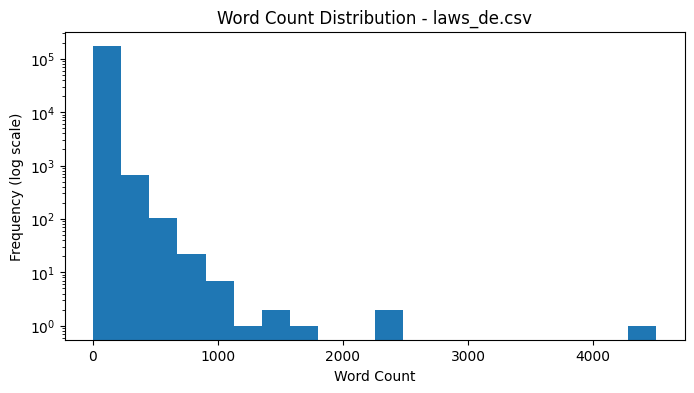


--- court_considerations.csv ---
Total rows: 2476315
Unique values in 'citation': 1985178

Unique values in 'text': 1958639



In [ ]:
# Check Citations in Laws and Court Datasets
print("Loading laws_de.csv...")
laws_df = pd.read_csv(os.path.join(DATADIR, 'laws_de.csv'))
laws_citations = set(laws_df['citation'].dropna())

print(f"Laws citations: {len(laws_citations)}")

all_gold_cits = train_cits | val_cits


court_df = pd.read_csv(os.path.join(DATADIR, 'court_considerations.csv'))
court_citations = set(court_df['citation'].dropna())


# citations missing from both sources
in_laws_or_count = all_gold_cits & (laws_citations | court_citations)
missing_from_both = all_gold_cits - (laws_citations | court_citations)


print(f"\nGold citations in laws or court considerations: {len(in_laws_or_count)}")
print(f"\nCitations missing from  laws or court: {len(missing_from_both)}")
print(f"Laws or Court coverage: {len(in_laws_or_count) / len(all_gold_cits):.3f}")

print("\nSample missing from both:", list(missing_from_both)[:10])

# Citations in both sources
in_both_sources = laws_citations & court_citations
print(f"\nCitations in both laws and court: {len(in_both_sources)}")

# Check for duplicated indices in laws_de and court_considerations
print("=" * 60)
print("UNIQUE INDEX ANALYSIS")
print("=" * 60)

# Laws dataset
print("\n--- laws_de.csv ---")
print(f"Total rows: {len(laws_df)}")
uni_laws = laws_df.nunique()
for col in laws_df.columns:
    print(f"Unique values in '{col}': {uni_laws[col]}\n")

# word count
laws_df['word_count'] = laws_df['text'].str.split().str.len()

plt.figure(figsize=(8,4))
plt.hist(laws_df['word_count'], bins=20, log=True)
plt.title('Word Count Distribution - laws_de.csv')
plt.xlabel('Word Count')
plt.ylabel('Frequency (log scale)')
plt.show()

# Court dataset
print("\n--- court_considerations.csv ---")
print(f"Total rows: {len(court_df)}")
uni_court = court_df.nunique()
for col in court_df.columns:
    print(f"Unique values in '{col}': {uni_court[col]}\n")

# word count
court_df['word_count'] = court_df['text'].str.split().str.len()
print(f"Word count stats:\n{court_df['word_count'].describe()}")

plt.figure(figsize=(8,4))
plt.hist(court_df['word_count'], bins=20, log=True)
plt.title('Word Count Distribution - court_considerations.csv')
plt.xlabel('Word Count')
plt.ylabel('Frequency (log scale)')
plt.show()


In [ ]:
laws_df.nunique()

citation       175933
text           160678
title           34784
text_length      2340
dtype: int64

### Insights: Citation Coverage in Retrieval Corpus
- **Combined Corpus Coverage**: Since gold citations include both legal articles and court decisions, coverage should be assessed against the union of both sources (laws + court).
- **Coverage Numbers**:
  - The combined laws and court datasets cover 2,111 of the 2,878 gold citations (73.3% coverage).
  - 767 citations are absent from both sources and cannot be retrieved from the provided data.
- **Implications for RAG**:
  - The retrieval corpus is incomplete, with about 27% of gold citations missing from the available data.
  - For missing citations, implement fallback strategies like "not found" or external lookups.
  - Treat laws and court as a single retrieval corpus for evaluation, as gold citations are mixed across both types.

### Overall Insights and Recommendations for Law RAG Development
- **Key Challenges**:
  - Long-tail citation distribution with many rare citations.
  - Incomplete retrieval corpus (27% of gold citations missing from combined laws and court data).
  - Domain shift between train/val splits.
  - Multi-label retrieval with variable citation counts per query.
- **RAG Architecture Recommendations**:
  - Use dense retrieval (e.g., bi-encoder) for semantic matching, as keyword matching may fail for complex legal queries.
  - Implement re-ranking with cross-encoders for better precision.
  - Handle missing citations by allowing "no match" predictions or fuzzy matching.
  - Balance training to avoid bias toward frequent citations.
  - Consider hierarchical retrieval: first retrieve relevant law sections, then specific articles.
- **Evaluation Considerations**:
  - Macro F1 emphasizes performance on all queries equally, including those with rare citations.
  - Monitor both precision (avoid false positives) and recall (find all relevant citations).
  - Test generalization across legal domains due to train/val differences.
- **Data Enhancement**:
  - Augment training with synthetic queries for rare citations.
  - Expand corpus if possible to include missing citations.
  - Use court considerations for case law context in retrieval.